In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.linalg import expm
from itertools import product

In [13]:
# number of Slater determinants
N = 1

a = 1
mu = -4
H = np.array([[a+mu,-a/2,-a/2,0],
              [-a/2,a,0,-a/2],
              [-a/2,0,a,-a/2],
              [0,-a/2,-a/2,a+mu]], dtype=complex)

def pair_index(a,b):
    # to get the index in the 2-particle basis LL LR RL RR
    return 2*a+b

def psi_rhs(t,f,psi,H,singular_tolerance=1e-12):
    """
    Here we define the equations for d_psi/dt, for all gamma, n (particle), and v (state L,R)

    Conventions:
    
    f.shape = (N,)
        f[gamma] = f_gamma(t)

    psi.shape = (N,2,2)
        psi[gamma, 0, 0] = psi_(gamma,1,L)
        psi[gamma, 0, 1] = psi_(gamma,1,R)
        psi[gamma, 1, 0] = psi_(gamma,2,L)
        psi[gamma, 1, 1] = psi_(gamma,2,R)

    H.shape = (4,4)
        Basis LL LR RL RR

    Returns
    d_psi : complex ndarray with shape (N,2,2)
        d_psi[gamma, 0, 0] = d_psi_(gamma,1,L)/dt
    """
    
    # number of slaters
    # N = len(f)

    # The equation contains 1/f_gamma.
    if np.any(np.abs(f) < singular_tolerance):
        bad_indices = np.where(np.abs(f) < singular_tolerance)[0]

        raise FloatingPointError(
            "The psi equation is singular because the following "
            f"f_gamma values are close to zero: gamma={bad_indices.tolist()}. "
            "The equation explicitly contains 1/f_gamma."    )

    # Make 2-particle ket for H |psi_beta,1  psi_beta,2 > where 1 and 2 are the particles 
    # in basis LL LR RL RR
    psi12 = np.einsum("k,l->kl", psi[0, :], psi[1, :]).reshape(4) # this is an outer product because b stays and doesnt get summed over
    # f_psi12_beta = f[:,np.newaxis] * psi12_beta 
    # # above, the newaxis allows us to multiply componentwise, so that f_beta for each beta is multiplied by all 4 entries of psi12 for that beta
    # f_psi12 = np.sum(f_psi12_beta,axis=0) # sum over beta
    # now apply the Hamiltonian:
    H_psi12 = H @ psi12


    # Now start making the equations of motion
    d_psi = np.zeros_like(psi, dtype=complex)

    # for gamma in range(N): # for the possible Slaters
    for v in range(2): # for 2 states L,R of the particle corresp to psi on LHS of equation
        
        # now we need 2 separate forms depending on if the equation is for the 1st particle or the second particle
        
        # if 1st particle: index=0
        total_n1 = 0.0j
        for j in range(2): # possible L,R of the other particle
            vj_index = pair_index(v,j) # index corresp to LL LR RL RR
            # sum over j:
            total_n1 += ( np.conj(psi[1,j]) * H_psi12[vj_index] )
            # above, psi function is for the other particle, therefore index 1. Term with H is that index because <vj|

        # differential equation for first particle wavefunction:
        d_psi[0,v] = -1j* total_n1

        
        # now same but if 2st particle: index=1
        total_n2 = 0.0j
        for j in range(2): # possible L,R of the other particle
            jv_index = pair_index(j,v) # NOW SWAPPED, index corresp to LL LR RL RR
            # sum over j:
            total_n2 += ( np.conj(psi[0,j]) * H_psi12[jv_index] )
            # above, psi function is for the other particle, therefore index 1. Term with H is that index because <vj|
        
        # differential equation for second particle wavefunction:
        d_psi[1,v] = -1j* total_n2

    # also need gammabar term:
    # this introduces an implicit system of linear equations that needs to be solved
    # the new term is encoded in the M matrix, 
    # where the row tells you which LHS dpsi component and column tells you what it depends on on the RHS of the equation

    # had this before but it wont work unless its all solved as a system 
    # d_psi[:,0,:] += -(fbar/f)[:,None] *( psibar[:,0,:]*np.sum(psi[:,1,:].conj()*d_psibar[:,1,:],axis=1)
    #                                    + d_psibar[:,0,:]*np.sum(psi[:,1,:].conj()*psibar[:,1,:],axis=1) )
    # d_psi[:,1,:] += -(fbar/f)[:,None] *( d_psibar[:,1,:]*np.sum(psi[:,0,:].conj()*psibar[:,0,:],axis=1)
    #                                    + psibar[:,1,:]*np.sum(psi[:,0,:].conj()*d_psibar[:,0,:],axis=1) )
    
    # if N > 2:
    #     raise NotImplementedError(
    #         "The implicit-system solve below assumes N=2 (gammabar = the other single "
    #         "determinant). For N>2 you'd need a sum over beta != gamma here instead, "
    #         "giving a bigger (but same-structure) linear system.")
    
    # gammabar_idx = np.array([1,0])         # for N=2 only
    
    # # now make the gammabar objects by swapping the gamma index
    # fbar = f[gammabar_idx]                  # shape (N,)
    # psibar = psi[gammabar_idx,:,:]          # shape (N,2,2)
    # c = fbar / f                            # coefficient, shape (N,)

    # dim = N*2*2
    # def idx(g,n,v): return g*4 + n*2 + v
    # M = np.zeros((dim,dim), dtype=complex) # row is LHS, col is RHS of my EOM

    # sum0 = np.sum(psi[:,0,:].conj() * psibar[:,0,:], axis=1)  # sum over j=L,R  shape (N,)
    # sum1 = np.sum(psi[:,1,:].conj() * psibar[:,1,:], axis=1)  # sum over j=L,R  shape (N,)
    
    # for gamma in range(N):
    #     gb = gammabar_idx[gamma]
    #     for v in range(2):
    #         # first the n=1 for LHS, determined by row of M:
    #         row = idx(gamma,0,v)
    #         for j in range(2): # for the sum
    #             col = idx(gb,1,j)
    #             M[row, col] += -c[gamma] * psibar[gamma,0,v] * np.conj(psi[gamma,1,j])
    #         col = idx(gb,0,v)
    #         M[row, col] += -c[gamma] * sum1[gamma]
            
    #         # now the n=2 for LHS, determined by row of M
    #         row = idx(gamma,1,v)
    #         for j in range(2): # for the sum
    #             col = idx(gb,0,j)
    #             M[row, col] += -c[gamma] * psibar[gamma,1,v] * np.conj(psi[gamma,0,j])
    #         col = idx(gb,1,v)
    #         M[row, col] += -c[gamma] * sum0[gamma]
    # # print(M)
    # # Now we actually solve the system, let x=d_psi as a (N*2*2,) long vector
    # # then x = base + Mx where M is a linear transformation -> solve (I-M)x = base for x to get the d_psi vector
    # base_vec = d_psi.ravel() # everything so far from above
    # x_vec = np.linalg.solve(np.eye(dim, dtype=complex) - M, base_vec)
    # d_psi = x_vec.reshape(N,2,2)
    
    # cond = np.linalg.cond(np.eye(dim, dtype=complex) - M)
    # print(f"t={t:.5f}  cond(I-M)={cond:.3e}  |f|={np.abs(f)}")
    return d_psi


def coupled_rhs(t,y,H,N):
    """
    Now the full coupled set of differential equations

    y contains: [all f (coefficient) values, all flattened psi (wavefunction) values]
    """

    f = y[:1]
    psi = y[1:].reshape(2,2)

    d_psi = psi_rhs(t,f,psi,H)

    # Now make the differential equations for the Slater weight functions f
    
    # term containing inner product with H: 
    # Make 2-particle ket for <psi_gamma,1  psi_gamma,2 | H |psi_beta,1  psi_beta,2 > where 1 and 2 are the particles 
    # create psi12[gamma], in basis LL LR RL RR
    psi12 = np.einsum("k,l->kl", psi[0, :], psi[1, :]).reshape(4)

    # now an NxN matrix with indices gamma,beta (from the two psi's)
    # (N, 4) @ (4, 4) @ (4, N) -> (N, N)
    V = psi12.conj() @ H @ psi12.T
    
    # matrix multiply with the f_beta functions to sum over beta
    # shape (N,) so now only depends on gamma:
    interaction = V * f

    # term containing derivative of psi
    # A[gamma] = sum_(p,u)  conjugate(psi[gamma,p,u])  d_psi[gamma,p,u]/dt
    A = np.sum( psi.conj() * d_psi, axis=(0,1) )
    # then multiply component-wise with f[gamma], not matrix multiplication, so that preserve gamma index: 

    # if N>2:
    #     raise FloatingPointError("More than 2 Slaters, CHANGE THE CODE (uncomment equivalent calculation in coupled_rhs)")
    
    # # Now the gamma^bar term. For two slaters gamma^bar is just the other slater (not gamma). There are 2 equivalent ways to do this, I have commented out one
    # # R = np.array([[0,1],[1,0]]) 
    # # psibar = np.einsum("ij,jkl->ikl",R,psi)
    # # d_psibar = np.einsum("ij,jkl->ikl",R,d_psi)
    # # fbar = R @ f
    # psibar = psi[[1,0],:,:]
    # d_psibar = d_psi[[1,0],:,:]
    # fbar = f[[1,0]]
    # gammabar = -fbar*( np.sum(psi[:,0,:].conj()*psibar[:,0,:],axis=1)*np.sum(psi[:,1,:].conj()*d_psibar[:,1,:],axis=1) 
    #               + np.sum(psi[:,0,:].conj()*d_psibar[:,0,:],axis=1)*np.sum(psi[:,1,:].conj()*psibar[:,1,:],axis=1) ) 
    # # above, axis is 1 because shape is (N,2) from selecting which particle

    # # IF THERE ARE MORE THAN 2 SLATERS, USE THE GENERALISED VERSION BELOW
    # # # overlap matrices between all pairs of Slater determinants (N,N)
    # # S1  = np.einsum('gi,bi->gb', psi[:,0,:].conj(),   psi[:,0,:])
    # # S2  = np.einsum('gj,bj->gb', psi[:,1,:].conj(),   psi[:,1,:])
    # # dS1 = np.einsum('gi,bi->gb', psi[:,0,:].conj(), d_psi[:,0,:])
    # # dS2 = np.einsum('gj,bj->gb', psi[:,1,:].conj(), d_psi[:,1,:])
    # # M = S1*dS2 + dS1*S2      # (N,N), indexed [gamma, beta]
    # # np.fill_diagonal(M, 0)   # excludes beta = gamma
    # # gammabar = -(M @ f)         # sum over beta, weighted by f_beta -> shape (N,)
    
    # differential equation for the Slater weightings
    d_f = -1j* interaction - A * f

    # want to return all the differential equations for f and then psi 
    return np.concatenate(( d_f, d_psi.ravel() ))


In [56]:
# initial conditions
f0 = np.array([1])
# f0 /= np.linalg.norm(f0)

psi0 = np.zeros((2, 2), dtype=complex)

# start both particles in the same state:
for particle in range(2):
    #slater0:
    psi0[particle,:] = np.array([1,0],dtype=complex)
    psi0[particle,:] /= np.linalg.norm(psi0[particle,:])
    print(psi0[particle,:])
    # #slater1:
    # psi0[1,particle,:] = np.array([0.3,-0.7],dtype=complex)
    # psi0[1,particle,:] /= np.linalg.norm(psi0[1,particle,:])
    # print(psi0[1,particle,:])

y0 = np.concatenate(( f0, psi0.ravel() ))


"""
Consistency checks for integration

'assert' continues on if answer is True, or raises error if False
""" 
assert H.shape == (4, 4)
assert f0.shape == (1,)
assert psi0.shape == (2, 2)
assert y0.shape == (1 + 4 * 1,)

# Evaluate the RHS once to catch indexing errors.
test_derivative = coupled_rhs(t=0.0, y=y0, H=H, N=N)
assert test_derivative.shape == y0.shape
assert np.all(np.isfinite(test_derivative))

print("Initial state shape:", y0.shape)
print("Initial derivative shape:", test_derivative.shape)


[1.+0.j 0.+0.j]
[1.+0.j 0.+0.j]
Initial state shape: (5,)
Initial derivative shape: (5,)


In [57]:
# Numerical integration

t_list = np.linspace(0.0,10.0,1001)
solution = solve_ivp( 
    fun=lambda t, y: coupled_rhs(t,y,H,N),
    t_span = (t_list[0],t_list[-1]), 
    y0 = y0,
    t_eval = t_list,
    method = "DOP853", # got same result with BDF and DOP853, crashes at same spot 
    rtol=1e-9,
    atol=1e-11,
)

if not solution.success:
    raise RuntimeError(
        f"Integration failed: {solution.message}"
    )

In [58]:
# store the solutions for f and psi separately 
print(solution.t[-2:], t_list[-1])   # how far did it get before failing?
print(solution.status, solution.message)

f_soln = solution.y[:1,:].reshape(len(solution.t))
# print(f_soln.shape,f_soln)
psi_soln = solution.y[1:,:].reshape(2,2,len(solution.t))
print("f_solution shape:", f_soln.shape)
print("psi_solution shape:", psi_soln.shape)

[ 9.99 10.  ] 10.0
0 The solver successfully reached the end of the integration interval.
f_solution shape: (1001,)
psi_solution shape: (2, 2, 1001)


In [42]:
# """
# Check orthogonality of the two slaters
# """
# slateroverlap = (
#         (psi_soln[0,0,0,:].conj()*psi_soln[1,0,0,:]
#         +psi_soln[0,0,1,:].conj()*psi_soln[1,0,1,:]) 
#       * (psi_soln[0,1,0,:].conj()*psi_soln[1,1,0,:]
#         +psi_soln[0,1,1,:].conj()*psi_soln[1,1,1,:])   )
# plt.plot(solution.t,np.abs(slateroverlap))
# plt.ylabel(r'$\langle \Phi^0 | \Phi^1 \rangle (t)$')
# plt.show()

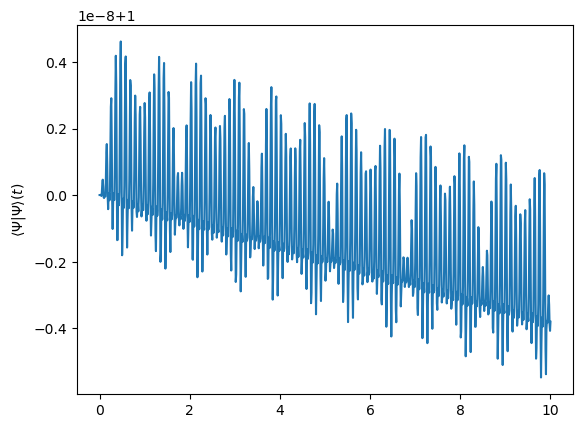

In [59]:
"""
Check normalisation of the FULL state
"""
slat0 = np.abs(f_soln)**2 * (
        (psi_soln[0,0,:].conj()*psi_soln[0,0,:]
        +psi_soln[0,1,:].conj()*psi_soln[0,1,:]) 
      * (psi_soln[1,0,:].conj()*psi_soln[1,0,:]
        +psi_soln[1,1,:].conj()*psi_soln[1,1,:])   )
# slat1 = np.abs(f_soln[1,:])**2 * (
#         (psi_soln[1,0,0,:].conj()*psi_soln[1,0,0,:]
#         +psi_soln[1,0,1,:].conj()*psi_soln[1,0,1,:]) 
#       * (psi_soln[1,1,0,:].conj()*psi_soln[1,1,0,:]
#         +psi_soln[1,1,1,:].conj()*psi_soln[1,1,1,:])   )
# cross = np.conj(f_soln[0,:])*f_soln[1,:] * (
#         (psi_soln[0,0,0,:].conj()*psi_soln[1,0,0,:]
#         +psi_soln[0,0,1,:].conj()*psi_soln[1,0,1,:]) 
#       * (psi_soln[0,1,0,:].conj()*psi_soln[1,1,0,:]
#         +psi_soln[0,1,1,:].conj()*psi_soln[1,1,1,:])   )
norm = slat0 #+ slat1 + cross + np.conj(cross)
plt.plot(solution.t,norm.real,label='real')
plt.ylabel(r'$\langle \Psi | \Psi \rangle (t)$')
# plt.plot(solution.t,norm.imag,label='imag')
plt.show()

(1001,)
(1001,)


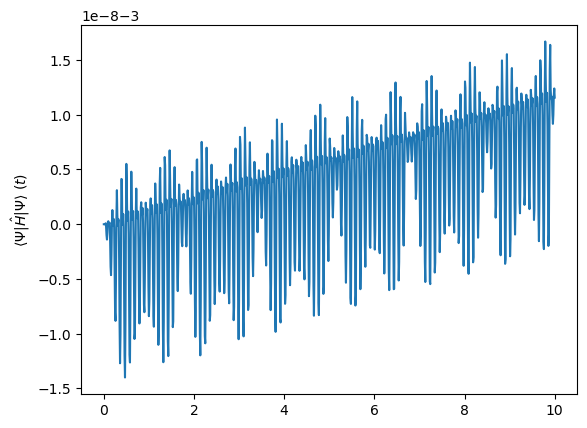

In [60]:
"""
Check Energy conservation
"""
slaters = np.einsum("kt,lt->klt",psi_soln[0, :, :],psi_soln[1, :, :]).reshape(4, len(solution.t))
slat0 = slaters
# slat1 = slaters[1,:,:]

Eslat0 = np.abs(f_soln)**2 * np.einsum("ti,ij,jt->t",slat0.T.conj(),H,slat0)
# Eslat1 = np.abs(f_soln[1,:])**2 * np.einsum("ti,ij,jt->t",slat1.T.conj(),H,slat1)
# Ecross = np.conj(f_soln[0,:])*f_soln[1,:] * np.einsum("ti,ij,jt->t",slat0.T.conj(),H,slat1)
# exE = Eslat0 + Eslat1 + Ecross + np.conj(Ecross)
print(Eslat0.shape)
print((np.abs(f_soln)**2).shape)

plt.plot(solution.t,Eslat0)
plt.ylabel(r'$\langle \Psi |\hat{H} | \Psi \rangle \ (t)$')
plt.show()

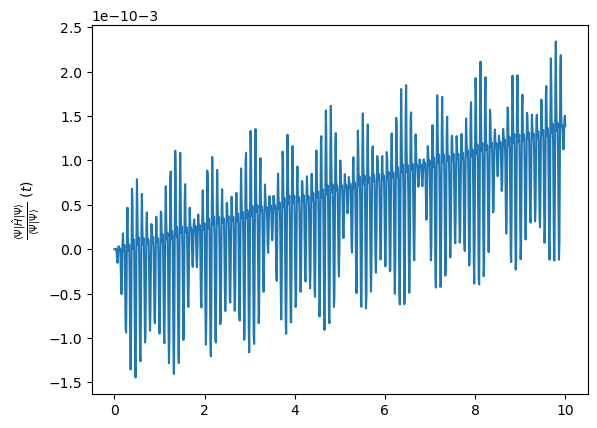

In [61]:
"""
Energy conservation divided by overlap, like in TDGCM paper
Still not constant idk man 
"""

plt.plot(solution.t,Eslat0/norm)
plt.ylabel(r'$\frac{\langle \Psi |\hat{H} | \Psi \rangle}{\langle \Psi | \Psi \rangle} \ (t)$')
plt.show()

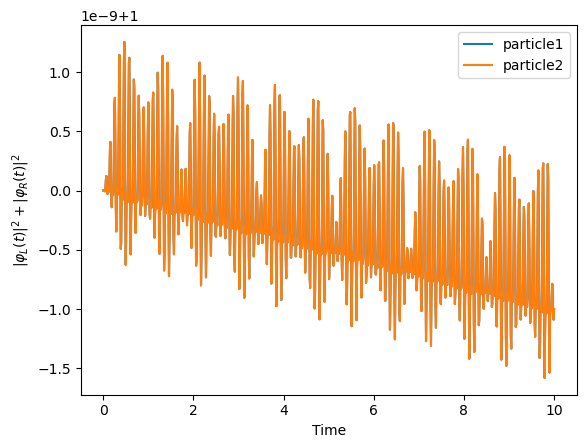

In [62]:
"""
Check Normalisation of single particle states
"""

plt.plot(
    solution.t,
    np.abs(psi_soln[0, 0, :])**2 + np.abs(psi_soln[0, 1, :])**2,
    label=fr"particle1")

plt.plot(
    solution.t,
    np.abs(psi_soln[1, 0, :])**2 + np.abs(psi_soln[1, 1, :])**2,
    label=fr"particle2")
plt.xlabel("Time")
plt.ylabel(r"$|\varphi_L(t)|^2+|\varphi_R(t)|^2$")
plt.legend()
plt.show()

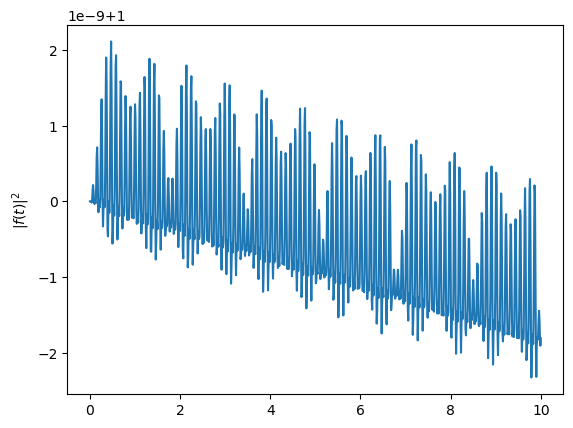

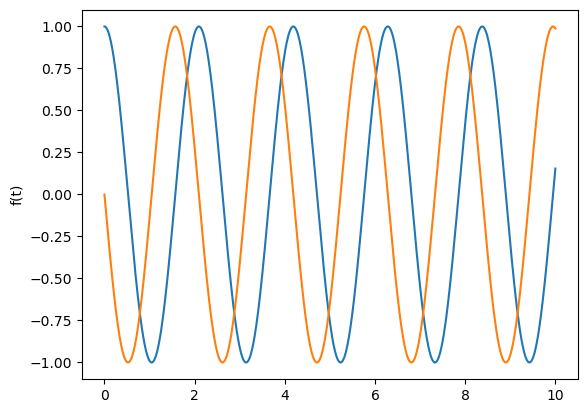

In [63]:
"""
Check normalisation of f Slater weighting
"""
plt.plot(solution.t,np.abs(f_soln)**2)
plt.ylabel(r'$|f(t)|^2$')
plt.show()

plt.plot(solution.t,f_soln.real,label='real')
plt.plot(solution.t,f_soln.imag,label='imag')
plt.ylabel(r'f(t)')
plt.show()

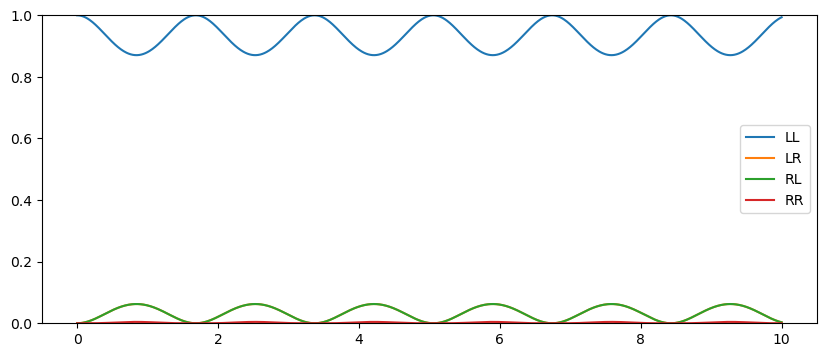

In [66]:
"""
Now check what actually happens to the evolution 
"""
# print(slat0[0].shape)
plt.figure(figsize=(10,4))
plt.plot(solution.t,np.abs(slat0[0])**2,label='LL')
plt.plot(solution.t,np.abs(slat0[1])**2,label='LR')
plt.plot(solution.t,np.abs(slat0[2])**2,label='RL')
plt.plot(solution.t,np.abs(slat0[3])**2,label='RR')
plt.ylim([0,1])
plt.legend()
plt.show()